Ground State Potential Energy Curve For H_2 Using HF

In [14]:
#makes a file containing all the energy for each bond length

# h2_hf_pec.py
import psi4
import numpy as np
import csv

#set basis
basis = "cc-pVTZ"

#max and min bond length
r_min, r_max, n_points = 0.2, 4.0, 100
csv_out = "h2_hf_pec.csv"
psi4_out = "psi4_h2_hf.out"


#rewrite over all files, don't append
psi4.core.set_output_file(psi4_out, False)
psi4.set_memory("2 GB")
psi4.set_num_threads(4)

#set up psi4
psi4.set_options({
    "basis": basis,
    "reference": "rhf", #restricted Hartree-Fock, needed for closed shell ssyt
    "e_convergence": 1e-10,
    "d_convergence": 1e-10,
    "maxiter": 200,
})

bond_lengths = np.linspace(r_min, r_max, n_points)
energies = []

for R in bond_lengths:
    mol = psi4.geometry(f"""
    0 1
    H
    H 1 {R}
    units angstrom
    symmetry c1
    """)
    psi4.core.clean()
    E = psi4.energy("scf", molecule=mol)
    energies.append((float(R), float(E)))
    #print(f"H2  RHF/{basis}  R={R:7.4f} Å  E={E: .12f} Eh")

with open(csv_out, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["R_angstrom", f"E_RHF_{basis}_Eh"])
    w.writerows(energies)

print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")



Saved h2_hf_pec.csv  |  Psi4 output: psi4_h2_hf.out


In [15]:
#makes a file containing all the energy for each bond length

# h2plus_hf_pec.py
import psi4
import numpy as np
import csv

#set basis
basis = "cc-pVTZ"

#max and min bond length
r_min, r_max, n_points = 0.2, 4.0, 100
csv_out = "h2plus_hf_pec.csv"
psi4_out = "psi4_h2plus_hf.out"


#rewrite over all files, don't append
psi4.core.set_output_file(psi4_out, False)
psi4.set_memory("2 GB")
psi4.set_num_threads(4)

#set up psi4
psi4.set_options({
    "basis": basis,
    "reference": "uhf", #unrestricted Hartree-Fock, needed for open shell system
    "e_convergence": 1e-10,
    "d_convergence": 1e-10,
    "maxiter": 200,
})

bond_lengths = np.linspace(r_min, r_max, n_points)
energies = []

for R in bond_lengths:
    mol = psi4.geometry(f"""
    1 2
    H
    H 1 {R}
    units angstrom
    symmetry c1
    """)
    psi4.core.clean()
    E = psi4.energy("scf", molecule=mol)
    energies.append((float(R), float(E)))
    #print(f"H2+  UHF/{basis}  R={R:7.4f} Å  E={E: .12f} Eh")

with open(csv_out, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["R_angstrom", f"E_UHF_{basis}_Eh"])
    w.writerows(energies)

print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")



Saved h2plus_hf_pec.csv  |  Psi4 output: psi4_h2plus_hf.out


In [16]:
#makes a file containing all the energy for each bond length

# h2_ccsd_pec.py
import psi4
import numpy as np
import csv

#set basis
basis = "cc-pVTZ"

#max and min bond length
r_min, r_max, n_points = 0.2, 4.0, 100
csv_out = "h2_ccsd_pec.csv"
psi4_out = "psi4_h2_ccsd.out"


#rewrite over all files, don't append
psi4.core.set_output_file(psi4_out, False)
psi4.set_memory("2 GB")
psi4.set_num_threads(4)

#set up psi4
psi4.set_options({
    "basis": basis,
    "reference": "rhf",
    "scf_type": "df",
    "e_convergence": 1e-10,
    "d_convergence": 1e-10,
    "maxiter": 200,
    "cc_type": "df",
    "freeze_core": False,
})

bond_lengths = np.linspace(r_min, r_max, n_points)
energies = []

for R in bond_lengths:
    mol = psi4.geometry(f"""
    0 1
    H
    H 1 {R}
    units angstrom
    symmetry c1
    """)
    psi4.core.clean()
    E = psi4.energy("ccsd", molecule=mol)
    energies.append((float(R), float(E)))
    #print(f"H2  CCSD/{basis}  R={R:7.4f} Å  E={E: .12f} Eh")

with open(csv_out, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["R_angstrom", f"E_CCSD_{basis}_Eh"])
    w.writerows(energies)

print(f"\nSaved {csv_out}  |  Psi4 output: {psi4_out}")



Saved h2_ccsd_pec.csv  |  Psi4 output: psi4_h2_ccsd.out


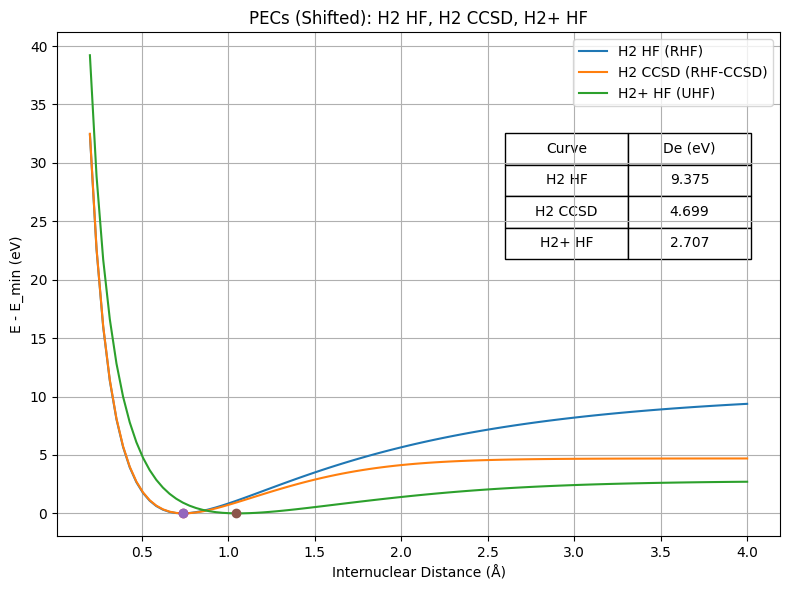

In [19]:
# plot_three_pecs.py
# Plots: H2 HF, H2 CCSD, H2+ HF (no H2+ CCSD)

import csv
import numpy as np
import matplotlib.pyplot as plt

def read_two_col_csv(path):
    R, E = [], []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        _ = next(reader)  # header
        for row in reader:
            if not row:
                continue
            R.append(float(row[0]))
            E.append(float(row[1]))
    return np.array(R), np.array(E)

# ---- Load data (filenames must match your outputs) ----
R_h2_hf,   E_h2_hf   = read_two_col_csv("h2_hf_pec.csv")
R_h2_ccsd, E_h2_ccsd = read_two_col_csv("h2_ccsd_pec.csv")
R_h2p_hf,  E_h2p_hf  = read_two_col_csv("h2plus_hf_pec.csv")


# ---- Shift each curve so its own minimum is 0 (nice for PEC comparison) ----
E_h2_hf_s   = E_h2_hf   - E_h2_hf.min()
E_h2_ccsd_s = E_h2_ccsd - E_h2_ccsd.min()
E_h2p_hf_s  = E_h2p_hf  - E_h2p_hf.min()


hartree_to_ev = 27.211396

E_h2_hf_eV   = E_h2_hf_s   * hartree_to_ev
E_h2_ccsd_eV = E_h2_ccsd_s * hartree_to_ev
E_h2p_hf_eV  = E_h2p_hf_s  * hartree_to_ev

# ---- Plot all three on one figure ----
plt.figure(figsize=(8,6))

# Plot smooth curves (no markers)
plt.plot(R_h2_hf,   E_h2_hf_eV,   linestyle="-",  label="H2 HF (RHF)")
plt.plot(R_h2_ccsd, E_h2_ccsd_eV, linestyle="-", label="H2 CCSD (RHF-CCSD)")
plt.plot(R_h2p_hf,  E_h2p_hf_eV,  linestyle="-", label="H2+ HF (UHF)")

# --- Find and plot the minimum point for each curve ---

# H2 HF minimum
min_idx = np.argmin(E_h2_hf_s)
plt.plot(R_h2_hf[min_idx], E_h2_hf_s[min_idx], 'o')

# H2 CCSD minimum
min_idx = np.argmin(E_h2_ccsd_s)
plt.plot(R_h2_ccsd[min_idx], E_h2_ccsd_s[min_idx], 'o')

# H2+ HF minimum
min_idx = np.argmin(E_h2p_hf_s)
plt.plot(R_h2p_hf[min_idx], E_h2p_hf_s[min_idx], 'o')


#Find dissociation energy

De_h2_hf_eV = E_h2_hf_eV[-1]
De_h2_ccsd_eV = E_h2_ccsd_eV[-1]
De_h2p_hf_eV = E_h2p_hf_eV[-1]



table_data = [
    ["H2 HF",   f"{De_h2_hf_eV:.3f}"],
    ["H2 CCSD", f"{De_h2_ccsd_eV:.3f}"],
    ["H2+ HF",  f"{De_h2p_hf_eV:.3f}"],
]

tbl = plt.table(
    cellText=table_data,
    colLabels=["Curve", "De (eV)"],
    cellLoc="center",
    colLoc="center",
    bbox=[0.62, 0.55, 0.34, 0.25],  # [left, bottom, width, height] in axes fraction
)

# Labels
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("E - E_min (eV)")
plt.title("PECs (Shifted): H2 HF, H2 CCSD, H2+ HF")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
